# Análisis Exploratorio de Datos de Ventas en E-commerce

# Autor: Eduardo Ferré Valderrama


## Introducción

Este notebook realiza un análisis exploratorio de datos (EDA) sobre un conjunto de datos de ventas en un e-commerce. El objetivo es explorar las características de los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.

El dataset contiene información sobre transacciones de ventas, incluyendo detalles del cliente, productos comprados, precios y fechas de compra. El análisis se centra en la identificación de tendencias de ventas, segmentación de clientes y análisis de productos.

Se utilizan bibliotecas como pandas, numpy, matplotlib y seaborn para la manipulación y visualización de datos. El análisis incluye la limpieza de datos, la exploración de variables, la identificación de valores atípicos y la creación de visualizaciones para comprender mejor los patrones en los datos.


## Importación de librerías y carga de datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

df = pd.read_csv("../data/ecommerce-dataset.csv")

## Vista preliminar e inspección general


In [2]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_method       51290 non-null 

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


Se inspecciona la estructura del dataset para entender cuántas columnas y registros tiene, así como los tipos de datos.

El dataset contiene **51.290 registros** y **16 columnas** que describen distintos aspectos de transacciones en una tienda online: datos del cliente (`Customer_Id`, `Gender`, `Device_Type`), del producto (`Product`, `Product_Category`, `Sales`, `Quantity`, etc.), y de la orden (`Order_Date`, `Time`, `Order_Priority`, `Payment_method`, etc.).

Observamos que las columnas `Order_Date` y `Time` están en formato `object`, por lo que se deberán convertir a formatos de fecha y hora (`datetime`) para facilitar análisis temporales.


## Análisis de valores nulos


In [3]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

Se detectaron valores nulos en 6 columnas, pero representaban menos del 0.01% del dataset. Por ello, se optará por eliminar las filas correspondientes para mantener la integridad del análisis sin afectar la muestra.


In [8]:
df.isnull()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Limpieza de datos


In [5]:
# Eliminamos duplicados 
df.drop_duplicates(inplace=True)

# Eliminamos filas con valores nulos
df.dropna(inplace=True)

# Convertimos fechas
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time


Se eliminan posibles filas duplicadas y aquellas que contienen valores nulos. También se realiza la conversión de los campos `Order_Date` y `Time` al formato adecuado, lo que permitirá agrupar por día, mes, año, o analizar el comportamiento horario.


## Análisis exploratorio de datos (EDA)


### Ventas Generales


In [11]:
# Total de ventas ($)
total_sales = df['Sales'].sum()
total_units = df['Quantity'].sum()

print(f"Total de ventas: ${total_sales:,.2f}")
print(f"Total de unidades vendidas: {int(total_units)}")


Total de ventas: $7,812,164.00
Total de unidades vendidas: 128357


El total de ventas registradas en el período es de aproximadamente **$7,812,164**, con un total de **128357 unidades vendidas**.

Ahora analizaremos cómo se distribuyen esas ventas a lo largo del tiempo.


#### Ventas por mes


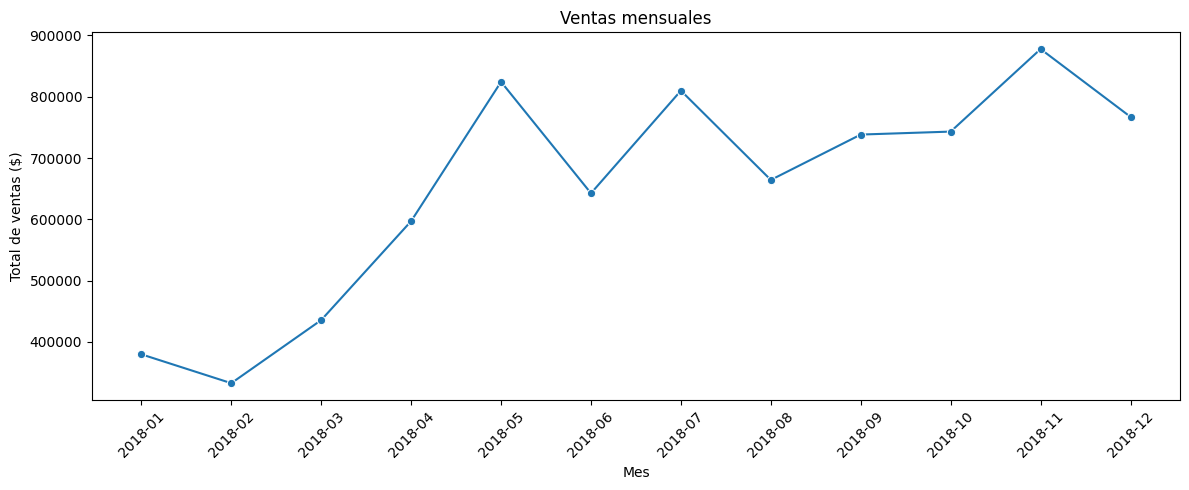

In [12]:
df['Order_Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Order_Month')['Sales'].sum().reset_index()
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', marker='o')
plt.xticks(rotation=45)
plt.title('Ventas mensuales')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


#### Ventas por día de la semana y hora


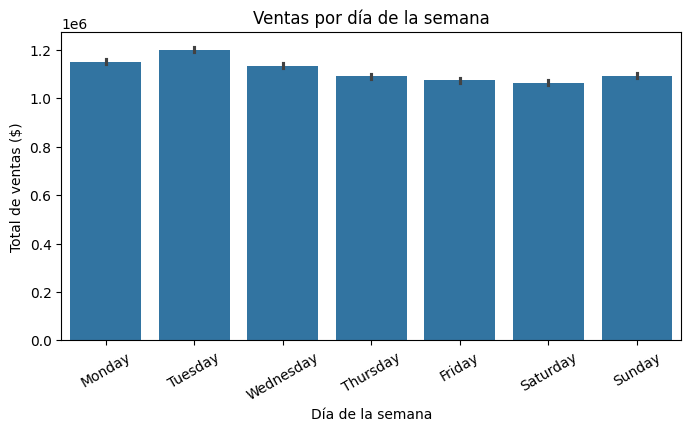

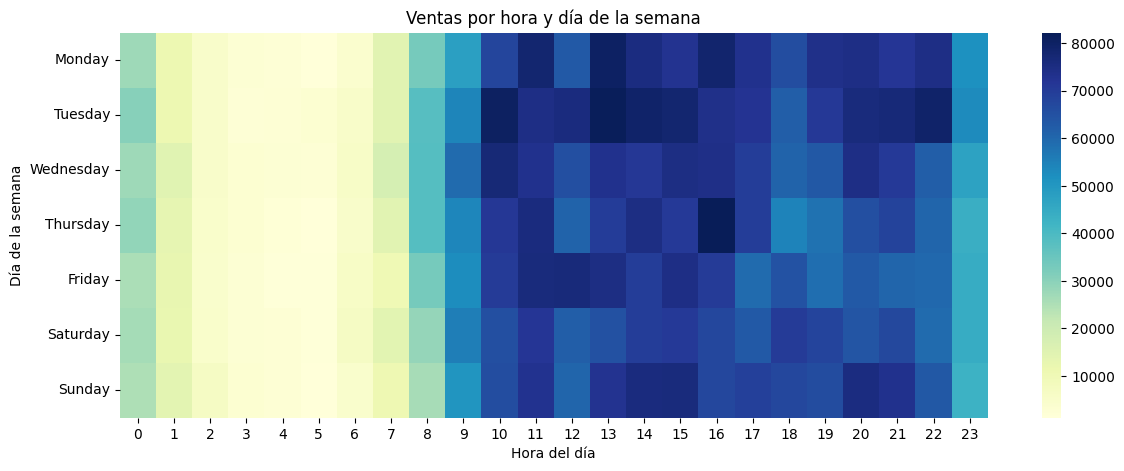

In [13]:
df['Weekday'] = df['Order_Date'].dt.day_name()
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Ventas por día de la semana
plt.figure(figsize=(8,4))
sns.barplot(x=df['Weekday'], y=df['Sales'], estimator=sum, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Ventas por día de la semana')
plt.ylabel('Total de ventas ($)')
plt.xlabel('Día de la semana')
plt.xticks(rotation=30)
plt.show()

# Heatmap de hora vs día
pivot = df.pivot_table(values='Sales', index='Weekday', columns='Hour', aggfunc='sum')
pivot = pivot.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(14,5))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Ventas por hora y día de la semana')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.show()
